# Plantilla de Extracción y Limpieza de Datos

### 1. Cargar un archivo desde Google Drive

Primero, montaremos Google Drive para acceder a tus archivos.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Configuración de la ruta del archivo

Define aquí la ruta a tu archivo CSV o Excel en Google Drive. Esta variable será usada por las celdas posteriores para cargar los datos.

In [2]:
# Define aquí la ruta a tu archivo CSV o Excel en Google Drive
# Ejemplo: '/content/drive/MyDrive/Kaggle/nombre_de_tu_archivo.csv'
file_path_global = '/content/drive/MyDrive/Kaggle/BostonHousing.csv'

print(f"Ruta del archivo configurada: {file_path_global}")

Ruta del archivo configurada: /content/drive/MyDrive/Kaggle/BostonHousing.csv


Ahora, puedes especificar la ruta de tu archivo CSV o Excel. **Asegúrate de reemplazar `'RUTA_A_TU_ARCHIVO.csv'` con la ruta real de tu archivo en Google Drive.**

Por ejemplo, si tu archivo está en `Mi Drive/Carpeta/mi_archivo.csv`, la ruta sería `/content/drive/MyDrive/Carpeta/mi_archivo.csv`.

### 3. Cargar el DataFrame

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
# Configurar estilo de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
try:
    # Si es un archivo CSV, usa pd.read_csv
    df = pd.read_csv(file_path_global)
    print("Archivo CSV cargado exitosamente.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: El archivo no se encontró en la ruta especificada: {file_path_global}")
    print("Por favor, verifica la ruta y asegúrate de que Google Drive esté montado correctamente.")
    df = None
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")
    df = None

Archivo CSV cargado exitosamente.


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### 4. Revisión inicial del DataFrame

Verifica las dimensiones, los tipos de datos y un resumen estadístico.

In [4]:
# Continuar solo si el DataFrame se cargó correctamente
if 'df' in locals() and df is not None:
    # Información general
    print(df.shape)
    print("\n")
    display(df.head())
    print("\n")
    display(df.info())
    print("\n")
    display(df.describe(include="all"))
else:
    print("El DataFrame 'df' no está cargado. Por favor, asegúrate de ejecutar la celda de carga de datos.")

(506, 14)




,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


None

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 5. Limpieza y estandarización de nombres de columnas

Estandarizamos los nombres de las columnas para facilitar el manejo.

In [5]:
if 'df' in locals() and df is not None:
    # Limpieza profesional de nombres de columnas
    df.columns = (
        df.columns
          .str.strip() # Elimina espacios en blanco al inicio y final
          .str.lower() # Convierte a minúsculas
          .str.replace(" ", "_", regex=False) # Reemplaza espacios con guiones bajos
          .str.replace("/", "_", regex=False) # Reemplaza barras con guiones bajos
          .str.replace("-", "_", regex=False) # Reemplaza guiones con guiones bajos
          .str.replace("__", "_", regex=False) # Reemplaza dobles guiones bajos con uno solo (por si acaso)
    )

    print("Nombres de columnas estandarizados:")
    print(df.columns.tolist())
else:
    print("El DataFrame 'df' no está cargado. Por favor, asegúrate de ejecutar la celda de carga de datos.")

Nombres de columnas estandarizados:
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']


### 6. Revisión de valores nulos y duplicados

In [6]:
if 'df' in locals() and df is not None:
    # Valores nulos
    nulos = df.isnull().sum().sort_values(ascending=False)
    print("Valores nulos por columna:")
    display(nulos[nulos > 0])

    # Duplicados
    print("\nDuplicados:\n", df.duplicated().sum())

    # Tipos de datos
    print("\nTipos de datos:\n")
    display(df.dtypes)
else:
    print("El DataFrame 'df' no está cargado. Por favor, asegúrate de ejecutar la celda de carga de datos.")

Valores nulos por columna:


,0



Duplicados:
 0

Tipos de datos:



,0
crim,float64
zn,float64
indus,float64
chas,int64
nox,float64
rm,float64
age,float64
dis,float64
rad,int64
tax,int64


### 7. Conversión y Validación de Columnas de Fecha

Convertir columnas que representan fechas a un formato `datetime` es crucial para análisis temporales. También validaremos que los identificadores numéricos sean del tipo correcto.

# Este dataset no contiene columnas de fecha.
# No se requiere conversión temporal.

In [ ]:
# Detectar automáticamente posibles columnas de fecha

if 'df' in locals() and df is not None:

    date_columns = []

    for col in df.select_dtypes(include='object').columns:

        # Intentar convertir sin mostrar warnings
        converted = pd.to_datetime(
            df[col],
            errors='coerce',
            format='mixed'
        )

        porcentaje_fecha = converted.notna().mean()

        # Si al menos el 70% puede interpretarse como fecha
        if porcentaje_fecha >= 0.70:
            df[col] = converted
            date_columns.append(col)

    print("Columnas detectadas como fecha:")

    if date_columns:
        for col in date_columns:
            print(f"✓ {col}")
    else:
        print("No se detectaron columnas de fecha.")

Columnas detectadas como fecha:
✓ month


In [ ]:
# Clasificar automáticamente las columnas del dataset

numeric_columns = df.select_dtypes(include='number').columns.tolist()
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
datetime_columns = df.select_dtypes(include=['datetime', 'datetimetz']).columns.tolist()

print("=== CLASIFICACIÓN DE COLUMNAS ===")

print("\nNuméricas:")
print(numeric_columns if numeric_columns else "Ninguna")

print("\nCategóricas / texto:")
print(categorical_columns if categorical_columns else "Ninguna")

print("\nFechas:")
print(datetime_columns if datetime_columns else "Ninguna")

=== CLASIFICACIÓN DE COLUMNAS ===

Numéricas:
['case_no', 'dob', 'cmi_value', 'los', 'severity', 'revenue']

Categóricas / texto:
['nationality', 'gender', 'doctorlicense', 'doctorname', 'doctor_type', 'doctor_status', 'specialty', 'insurance_payer', 'insuranceplanname', 'payer_mix', 'case_type', 'surgical_mix', 'discharge_time', 'discharge_before_12pm']

Fechas:
['month']


### 8. Estandarización de Datos Categóricos

Aseguramos que los valores en columnas categóricas sean consistentes, por ejemplo, convirtiendo a minúsculas o reemplazando variantes.

# No se requiere estandarización de variables categóricas de texto.
# El dataset contiene variables numéricas y categorías ya codificadas.

In [ ]:
# Estandarización automática de variables categóricas

for col in df.select_dtypes(include=['object', 'category']).columns:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

print("=== VARIABLES CATEGÓRICAS ESTANDARIZADAS ===")

categorical_cols = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(categorical_cols if categorical_cols else "No se detectaron variables categóricas.")

=== VARIABLES CATEGÓRICAS ESTANDARIZADAS ===
['nationality', 'gender', 'doctorlicense', 'doctorname', 'doctor_type', 'doctor_status', 'specialty', 'insurance_payer', 'insuranceplanname', 'payer_mix', 'case_type', 'surgical_mix', 'discharge_time', 'discharge_before_12pm']


In [7]:
# Perfil automático de calidad de datos

quality_report = pd.DataFrame({
    'columna': df.columns,
    'tipo': df.dtypes.astype(str).values,
    'nulos': df.isnull().sum().values,
    'nulos_%': (df.isnull().mean() * 100).round(2).values,
    'unicos': df.nunique(dropna=False).values
})

quality_report['duplicados_dataset'] = df.duplicated().sum()

print("=== REPORTE DE CALIDAD ===")
display(quality_report)

print("\nFilas duplicadas:", df.duplicated().sum())
print("Total de filas:", len(df))
print("Total de columnas:", len(df.columns))

=== REPORTE DE CALIDAD ===


,columna,tipo,nulos,nulos_%,unicos,duplicados_dataset
0,crim,float64,0,0.0,504,0
1,zn,float64,0,0.0,26,0
2,indus,float64,0,0.0,76,0
3,chas,int64,0,0.0,2,0
4,nox,float64,0,0.0,81,0
5,rm,float64,0,0.0,446,0
6,age,float64,0,0.0,356,0
7,dis,float64,0,0.0,412,0
8,rad,int64,0,0.0,9,0
9,tax,int64,0,0.0,66,0



Filas duplicadas: 0
Total de filas: 506
Total de columnas: 14


In [8]:
# Detectar automáticamente el rol probable de cada columna

column_roles = []

for col in df.columns:

    unique_ratio = df[col].nunique(dropna=False) / len(df)
    col_lower = col.lower()

    # Fecha
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        role = "fecha"

    # Posible ID: alta unicidad + nombre compatible con identificador
    elif (
        unique_ratio >= 0.95
        and any(x in col_lower for x in ['id', 'code', 'codigo', 'case_no', 'number', 'numero'])
    ):
        role = "posible_id"

    # Numéricas
    elif pd.api.types.is_numeric_dtype(df[col]):

        if df[col].nunique() <= 10:
            role = "numerica_discreta"
        else:
            role = "numerica_continua"

    # Texto / categorías
    else:

        if df[col].nunique() <= 20:
            role = "categorica"
        else:
            role = "texto_alta_cardinalidad"

    column_roles.append({
        "columna": col,
        "rol_probable": role,
        "valores_unicos": df[col].nunique(),
        "ratio_unicidad": round(unique_ratio, 3)
    })

roles_report = pd.DataFrame(column_roles)

print("=== ROLES PROBABLES DE LAS COLUMNAS ===")
display(roles_report)

=== ROLES PROBABLES DE LAS COLUMNAS ===


,columna,rol_probable,valores_unicos,ratio_unicidad
0,crim,numerica_continua,504,0.996
1,zn,numerica_continua,26,0.051
2,indus,numerica_continua,76,0.150
3,chas,numerica_discreta,2,0.004
4,nox,numerica_continua,81,0.160
5,rm,numerica_continua,446,0.881
6,age,numerica_continua,356,0.704
7,dis,numerica_continua,412,0.814
8,rad,numerica_discreta,9,0.018
9,tax,numerica_continua,66,0.130


In [9]:
# Seleccionar automáticamente variables útiles para análisis

ids = roles_report.loc[
    roles_report['rol_probable'] == 'posible_id',
    'columna'
].tolist()

fechas = roles_report.loc[
    roles_report['rol_probable'] == 'fecha',
    'columna'
].tolist()

categoricas = roles_report.loc[
    roles_report['rol_probable'] == 'categorica',
    'columna'
].tolist()

numericas = roles_report.loc[
    roles_report['rol_probable'].isin(
        ['numerica_continua', 'numerica_discreta']
    ),
    'columna'
].tolist()

print("=== VARIABLES DISPONIBLES PARA ANÁLISIS ===")

print("\nIDs (se excluyen del análisis):")
print(ids if ids else "Ninguno")

print("\nFechas:")
print(fechas if fechas else "Ninguna")

print("\nCategóricas:")
print(categoricas if categoricas else "Ninguna")

print("\nNuméricas:")
print(numericas if numericas else "Ninguna")

=== VARIABLES DISPONIBLES PARA ANÁLISIS ===

IDs (se excluyen del análisis):
Ninguno

Fechas:
Ninguna

Categóricas:
Ninguna

Numéricas:
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']


In [11]:
# Evaluar potencial analítico de las variables

analysis_candidates = []

for col in df.columns:

    role = roles_report.loc[
        roles_report['columna'] == col,
        'rol_probable'
    ].values[0]

    score = 0
    motivos = []

    if role == "fecha":
        score += 2
        motivos.append("permite análisis temporal")

    elif role == "categorica":
        unique_count = df[col].nunique()

        if 2 <= unique_count <= 15:
            score += 3
            motivos.append("buena segmentación")

        elif unique_count <= 30:
            score += 2
            motivos.append("segmentación posible")

    elif role in ["numerica_continua", "numerica_discreta"]:
        score += 3
        motivos.append("permite métricas y comparaciones")

        if df[col].std() > 0:
            score += 1
            motivos.append("presenta variabilidad")

    elif role == "posible_id":
        motivos.append("identificador; baja utilidad analítica directa")

    analysis_candidates.append({
        "columna": col,
        "rol": role,
        "score_analitico": score,
        "motivos": ", ".join(motivos)
    })

potential_report = pd.DataFrame(analysis_candidates)

potential_report = potential_report.sort_values(
    by="score_analitico",
    ascending=False
)

print("=== POTENCIAL ANALÍTICO DE LAS VARIABLES ===")
display(potential_report)

=== POTENCIAL ANALÍTICO DE LAS VARIABLES ===


,columna,rol,score_analitico,motivos
0,crim,numerica_continua,4,"permite métricas y comparaciones, presenta var..."
1,zn,numerica_continua,4,"permite métricas y comparaciones, presenta var..."
2,indus,numerica_continua,4,"permite métricas y comparaciones, presenta var..."
3,chas,numerica_discreta,4,"permite métricas y comparaciones, presenta var..."
4,nox,numerica_continua,4,"permite métricas y comparaciones, presenta var..."
5,rm,numerica_continua,4,"permite métricas y comparaciones, presenta var..."
6,age,numerica_continua,4,"permite métricas y comparaciones, presenta var..."
7,dis,numerica_continua,4,"permite métricas y comparaciones, presenta var..."
8,rad,numerica_discreta,4,"permite métricas y comparaciones, presenta var..."
9,tax,numerica_continua,4,"permite métricas y comparaciones, presenta var..."


In [12]:
# Buscar relaciones prometedoras con medidas comparables

promising_relations = []

# 1. Numérica vs categórica: Eta cuadrado
for num_col in numericas:
    for cat_col in categoricas:

        if 2 <= df[cat_col].nunique() <= 15:

            temp = df[[num_col, cat_col]].dropna()

            if len(temp) > 1:

                media_general = temp[num_col].mean()

                ss_total = ((temp[num_col] - media_general) ** 2).sum()

                ss_between = sum(
                    len(grupo) * (grupo[num_col].mean() - media_general) ** 2
                    for _, grupo in temp.groupby(cat_col)
                )

                if ss_total > 0:
                    eta2 = ss_between / ss_total

                    if eta2 >= 0.05:
                        promising_relations.append({
                            "tipo": "numerica_vs_categorica",
                            "variable_1": num_col,
                            "variable_2": cat_col,
                            "fuerza": round(eta2, 3),
                            "motivo": "diferencias relevantes entre categorías"
                        })

# 2. Numérica vs numérica: correlación
for i in range(len(numericas)):
    for j in range(i + 1, len(numericas)):

        col1 = numericas[i]
        col2 = numericas[j]

        corr = df[[col1, col2]].corr().iloc[0, 1]

        if pd.notna(corr) and abs(corr) >= 0.30:
            promising_relations.append({
                "tipo": "numerica_vs_numerica",
                "variable_1": col1,
                "variable_2": col2,
                "fuerza": round(abs(corr), 3),
                "motivo": f"correlación {round(corr, 2)}"
            })

relations_report = pd.DataFrame(promising_relations)

print("=== RELACIONES PROMETEDORAS ===")

if relations_report.empty:
    print("No se detectaron relaciones destacables.")
else:
    relations_report = relations_report.sort_values(
        by="fuerza",
        ascending=False
    )

    display(relations_report.head(20))

=== RELACIONES PROMETEDORAS ===


,tipo,variable_1,variable_2,fuerza,motivo
48,numerica_vs_numerica,rad,tax,0.910,correlación 0.91
31,numerica_vs_numerica,nox,dis,0.769,correlación -0.77
19,numerica_vs_numerica,indus,nox,0.764,correlación 0.76
40,numerica_vs_numerica,age,dis,0.748,correlación -0.75
61,numerica_vs_numerica,lstat,medv,0.738,correlación -0.74
30,numerica_vs_numerica,nox,age,0.731,correlación 0.73
24,numerica_vs_numerica,indus,tax,0.721,correlación 0.72
22,numerica_vs_numerica,indus,dis,0.708,correlación -0.71
39,numerica_vs_numerica,rm,medv,0.695,correlación 0.7
33,numerica_vs_numerica,nox,tax,0.668,correlación 0.67


In [13]:
# Generar candidatos de hallazgo en lenguaje natural

hallazgos = []

for _, row in relations_report.iterrows():

    tipo = row["tipo"]
    var1 = row["variable_1"]
    var2 = row["variable_2"]
    fuerza = row["fuerza"]

    if tipo == "numerica_vs_categorica":

        if fuerza >= 0.50:
            nivel = "muy marcada"
        elif fuerza >= 0.20:
            nivel = "moderada"
        else:
            nivel = "leve"

        texto = (
            f"La variable '{var1}' presenta una diferencia {nivel} "
            f"según las categorías de '{var2}' "
            f"(fuerza = {fuerza})."
        )

    elif tipo == "numerica_vs_numerica":

        if fuerza >= 0.70:
            nivel = "fuerte"
        elif fuerza >= 0.50:
            nivel = "moderada"
        else:
            nivel = "débil"

        texto = (
            f"Existe una relación {nivel} entre '{var1}' y '{var2}' "
            f"(fuerza = {fuerza})."
        )

    hallazgos.append({
        "variable_1": var1,
        "variable_2": var2,
        "fuerza": fuerza,
        "candidato_hallazgo": texto
    })

hallazgos_report = pd.DataFrame(hallazgos)

print("=== CANDIDATOS DE HALLAZGO ===")

if hallazgos_report.empty:
    print("No se generaron candidatos de hallazgo.")
else:
    display(hallazgos_report)

=== CANDIDATOS DE HALLAZGO ===


,variable_1,variable_2,fuerza,candidato_hallazgo
0,rad,tax,0.910,Existe una relación fuerte entre 'rad' y 'tax'...
1,nox,dis,0.769,Existe una relación fuerte entre 'nox' y 'dis'...
2,indus,nox,0.764,Existe una relación fuerte entre 'indus' y 'no...
3,age,dis,0.748,Existe una relación fuerte entre 'age' y 'dis'...
4,lstat,medv,0.738,Existe una relación fuerte entre 'lstat' y 'me...
...,...,...,...,...
57,b,medv,0.333,Existe una relación débil entre 'b' y 'medv' (...
58,zn,tax,0.315,Existe una relación débil entre 'zn' y 'tax' (...
59,zn,rm,0.312,Existe una relación débil entre 'zn' y 'rm' (f...
60,zn,rad,0.312,Existe una relación débil entre 'zn' y 'rad' (...


In [14]:
# Generar evidencia automática para los candidatos de hallazgo

evidencias = []

for _, row in relations_report.iterrows():

    tipo = row["tipo"]
    var1 = row["variable_1"]
    var2 = row["variable_2"]
    fuerza = row["fuerza"]

    if tipo == "numerica_vs_categorica":

        resumen = (
            df.groupby(var2)[var1]
            .agg(["count", "mean", "median"])
            .round(2)
            .reset_index()
            .sort_values("mean", ascending=False)
        )

        top = resumen.iloc[0]
        bottom = resumen.iloc[-1]

        evidencias.append({
            "variable_1": var1,
            "variable_2": var2,
            "fuerza": fuerza,
            "evidencia": (
                f"Mayor promedio: {top[var2]} = {top['mean']}. "
                f"Menor promedio: {bottom[var2]} = {bottom['mean']}. "
                f"Diferencia = {round(top['mean'] - bottom['mean'], 2)}."
            )
        })

    elif tipo == "numerica_vs_numerica":

        corr = df[[var1, var2]].corr().iloc[0, 1]

        evidencias.append({
            "variable_1": var1,
            "variable_2": var2,
            "fuerza": fuerza,
            "evidencia": (
                f"Correlación = {round(corr, 2)}. "
                f"A mayor '{var1}', {'tiende a aumentar' if corr > 0 else 'tiende a disminuir'} '{var2}'."
            )
        })

evidence_report = pd.DataFrame(evidencias)

print("=== EVIDENCIA DE LOS CANDIDATOS ===")

if evidence_report.empty:
    print("No se generó evidencia.")
else:
    display(evidence_report)

=== EVIDENCIA DE LOS CANDIDATOS ===


,variable_1,variable_2,fuerza,evidencia
0,rad,tax,0.910,"Correlación = 0.91. A mayor 'rad', tiende a au..."
1,nox,dis,0.769,"Correlación = -0.77. A mayor 'nox', tiende a d..."
2,indus,nox,0.764,"Correlación = 0.76. A mayor 'indus', tiende a ..."
3,age,dis,0.748,"Correlación = -0.75. A mayor 'age', tiende a d..."
4,lstat,medv,0.738,"Correlación = -0.74. A mayor 'lstat', tiende a..."
...,...,...,...,...
57,b,medv,0.333,"Correlación = 0.33. A mayor 'b', tiende a aume..."
58,zn,tax,0.315,"Correlación = -0.31. A mayor 'zn', tiende a di..."
59,zn,rm,0.312,"Correlación = 0.31. A mayor 'zn', tiende a aum..."
60,zn,rad,0.312,"Correlación = -0.31. A mayor 'zn', tiende a di..."


In [15]:
# Puntuar candidatos de hallazgo

scored_findings = []

for _, row in evidence_report.iterrows():

    fuerza = row["fuerza"]
    var1 = row["variable_1"]
    var2 = row["variable_2"]
    evidencia = row["evidencia"]

    score = 0

    # Fuerza estadística
    if fuerza >= 0.70:
        score += 3
    elif fuerza >= 0.40:
        score += 2
    elif fuerza >= 0.10:
        score += 1

    # Variables numéricas o categóricas útiles
    if var1 in numericas:
        score += 1

    if var2 in categoricas or var2 in numericas:
        score += 1

    # Clasificación final
    if score >= 5:
        nivel = "Hallazgo fuerte"
    elif score >= 3:
        nivel = "Hallazgo medio"
    else:
        nivel = "Exploratorio"

    scored_findings.append({
        "variable_1": var1,
        "variable_2": var2,
        "fuerza": fuerza,
        "score": score,
        "nivel": nivel,
        "evidencia": evidencia
    })

findings_score_report = pd.DataFrame(scored_findings)

findings_score_report = findings_score_report.sort_values(
    by=["score", "fuerza"],
    ascending=False
)

print("=== RANKING DE HALLAZGOS ===")

if findings_score_report.empty:
    print("No se encontraron hallazgos.")
else:
    display(findings_score_report)

=== RANKING DE HALLAZGOS ===


,variable_1,variable_2,fuerza,score,nivel,evidencia
0,rad,tax,0.910,5,Hallazgo fuerte,"Correlación = 0.91. A mayor 'rad', tiende a au..."
1,nox,dis,0.769,5,Hallazgo fuerte,"Correlación = -0.77. A mayor 'nox', tiende a d..."
2,indus,nox,0.764,5,Hallazgo fuerte,"Correlación = 0.76. A mayor 'indus', tiende a ..."
3,age,dis,0.748,5,Hallazgo fuerte,"Correlación = -0.75. A mayor 'age', tiende a d..."
4,lstat,medv,0.738,5,Hallazgo fuerte,"Correlación = -0.74. A mayor 'lstat', tiende a..."
...,...,...,...,...,...,...
57,b,medv,0.333,3,Hallazgo medio,"Correlación = 0.33. A mayor 'b', tiende a aume..."
58,zn,tax,0.315,3,Hallazgo medio,"Correlación = -0.31. A mayor 'zn', tiende a di..."
59,zn,rm,0.312,3,Hallazgo medio,"Correlación = 0.31. A mayor 'zn', tiende a aum..."
60,zn,rad,0.312,3,Hallazgo medio,"Correlación = -0.31. A mayor 'zn', tiende a di..."


In [16]:
# Evaluar aptitud del dataset para un caso BI / portfolio

score = 0
criterios = []

# Tamaño
if len(df) >= 5000:
    score += 2
    criterios.append("Buen volumen de registros")
elif len(df) >= 500:
    score += 1
    criterios.append("Volumen aceptable")
else:
    criterios.append("Dataset pequeño")

# Variedad de columnas
if len(df.columns) >= 10:
    score += 1
    criterios.append("Buena variedad de variables")

# Variables numéricas
if len(numericas) >= 2:
    score += 2
    criterios.append("Tiene métricas suficientes")

# Variables categóricas
if len(categoricas) >= 2:
    score += 2
    criterios.append("Permite segmentación")

# Fechas
if len(fechas) >= 1:
    score += 1
    criterios.append("Permite análisis temporal")

# Relaciones prometedoras
hallazgos_fuertes = len(
    findings_score_report[
        findings_score_report["nivel"] == "Hallazgo fuerte"
    ]
)

hallazgos_medios = len(
    findings_score_report[
        findings_score_report["nivel"] == "Hallazgo medio"
    ]
)

if hallazgos_fuertes >= 2:
    score += 2
    criterios.append("Tiene varios hallazgos fuertes")
elif hallazgos_fuertes >= 1 or hallazgos_medios >= 2:
    score += 1
    criterios.append("Tiene potencial analítico")

# Clasificación final
if score >= 8:
    resultado = "MUY APTO PARA PORTFOLIO"
elif score >= 6:
    resultado = "APTO PARA PORTFOLIO"
elif score >= 4:
    resultado = "APTITUD MEDIA - REVISAR"
else:
    resultado = "POCO APTO PARA PORTFOLIO"

print("=== PORTFOLIO SCORE ===")
print(f"\nScore: {score}/10")
print(f"Resultado: {resultado}")

print("\nCriterios:")
for criterio in criterios:
    print("•", criterio)

=== PORTFOLIO SCORE ===

Score: 6/10
Resultado: APTO PARA PORTFOLIO

Criterios:
• Volumen aceptable
• Buena variedad de variables
• Tiene métricas suficientes
• Tiene varios hallazgos fuertes


## Estadísticas descriptivas y visualizaciones 📊

En esta sección se presentan estadísticas clave y visualizaciones que permiten comprender mejor el comportamiento del mercado inmobiliario en Boston. Cada gráfico se acompaña de una breve interpretación para facilitar la toma de decisiones por parte de la alta gerencia.


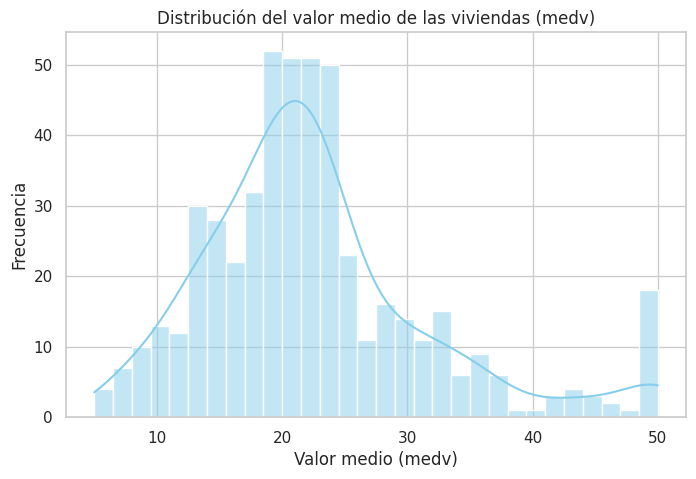

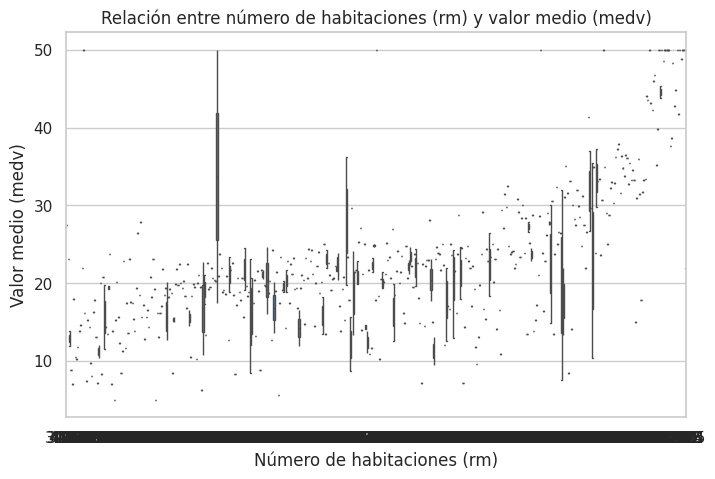

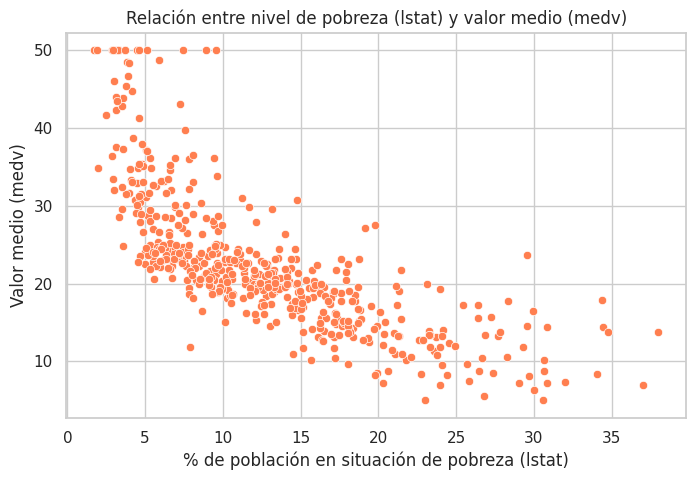

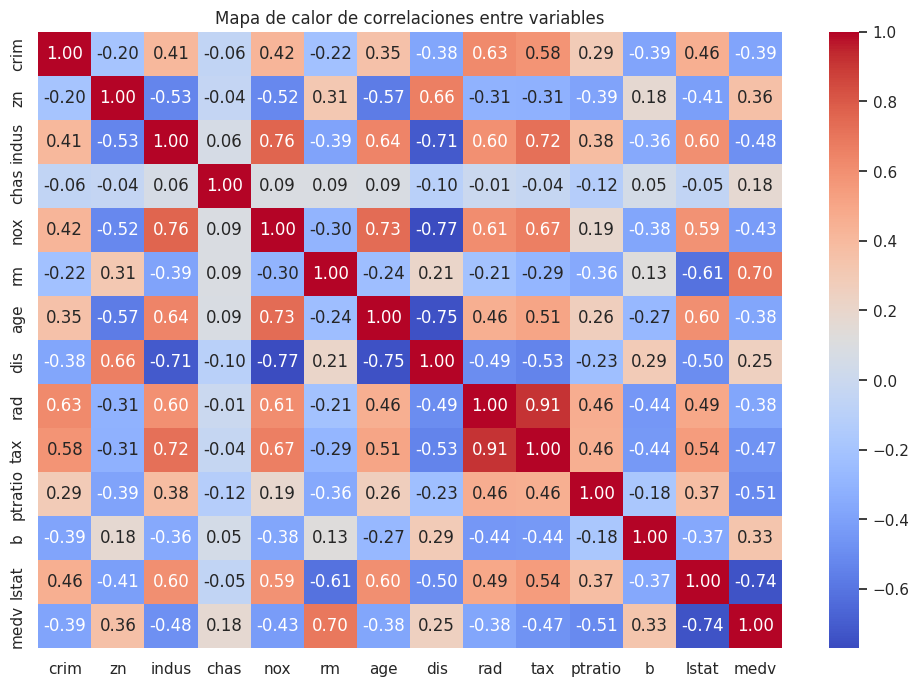

In [19]:
# Histograma del valor medio de las viviendas
plt.figure(figsize=(8, 5))
sns.histplot(df['medv'], bins=30, kde=True, color='skyblue')
plt.title('Distribución del valor medio de las viviendas (medv)')
plt.xlabel('Valor medio (medv)')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot de número de habitaciones vs valor medio
plt.figure(figsize=(8, 5))
sns.boxplot(x='rm', y='medv', data=df)
plt.title('Relación entre número de habitaciones (rm) y valor medio (medv)')
plt.xlabel('Número de habitaciones (rm)')
plt.ylabel('Valor medio (medv)')
plt.show()

# Gráfico de dispersión entre nivel de pobreza y valor medio
plt.figure(figsize=(8, 5))
sns.scatterplot(x='lstat', y='medv', data=df, color='coral')
plt.title('Relación entre nivel de pobreza (lstat) y valor medio (medv)')
plt.xlabel('% de población en situación de pobreza (lstat)')
plt.ylabel('Valor medio (medv)')
plt.show()

# Mapa de calor de correlaciones
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de calor de correlaciones entre variables')
plt.show()

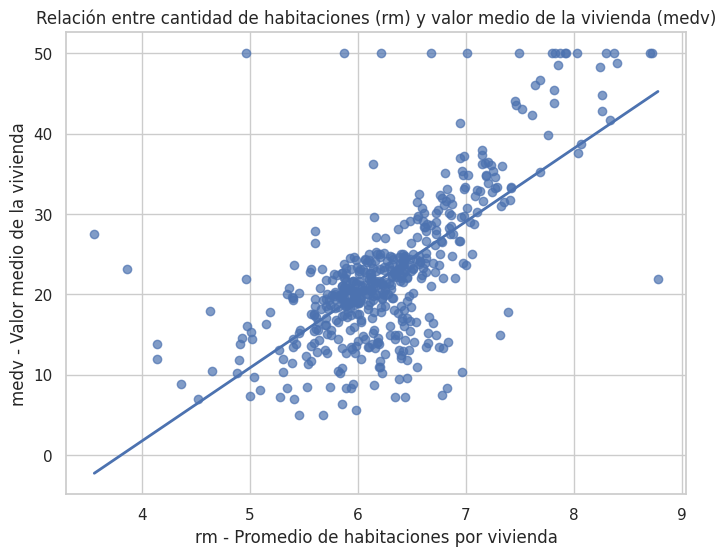

In [26]:
# Scatter RM vs MEDV con línea de tendencia

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['rm'], df['medv'], alpha=0.7)

# Línea de tendencia
m, b = np.polyfit(df['rm'], df['medv'], 1)
x = np.linspace(df['rm'].min(), df['rm'].max(), 100)
plt.plot(x, m * x + b, linewidth=2)

plt.title('Relación entre cantidad de habitaciones (rm) y valor medio de la vivienda (medv)')
plt.xlabel('rm - Promedio de habitaciones por vivienda')
plt.ylabel('medv - Valor medio de la vivienda')
plt.grid(True)
plt.show()

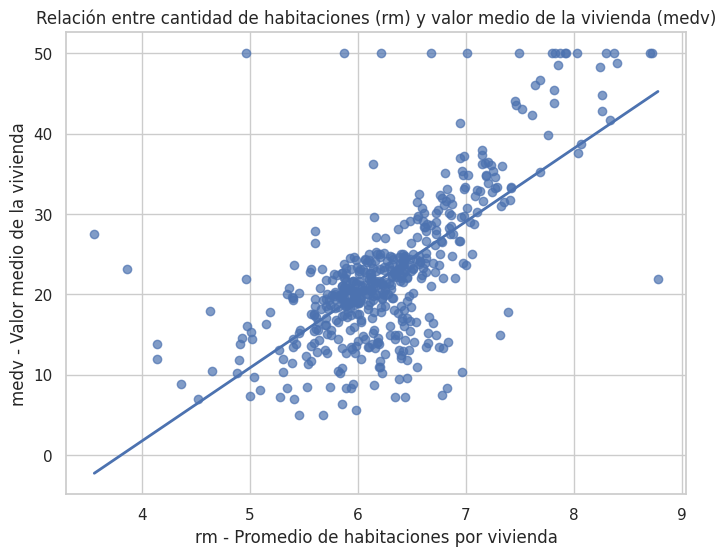

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(df['rm'], df['medv'], alpha=0.7)

m, b = np.polyfit(df['rm'], df['medv'], 1)
x = np.linspace(df['rm'].min(), df['rm'].max(), 100)
plt.plot(x, m * x + b, linewidth=2)

plt.title('Relación entre cantidad de habitaciones (rm) y valor medio de la vivienda (medv)')
plt.xlabel('rm - Promedio de habitaciones por vivienda')
plt.ylabel('medv - Valor medio de la vivienda')
plt.grid(True)

plt.savefig('rm_vs_medv_tendencia.png', dpi=300, bbox_inches='tight')
plt.show()

## Conclusiones de la exploración 📌

- El valor medio de las viviendas (`medv`) se concentra entre los 20 y 25 mil dólares, con algunos valores extremos que podrían representar propiedades de lujo o errores de medición.
- Existe una relación positiva entre el número de habitaciones (`rm`) y el valor medio de la vivienda: más habitaciones tienden a asociarse con mayor valor.
- Se observa una fuerte relación negativa entre el porcentaje de población en situación de pobreza (`lstat`) y el valor de las viviendas, lo que indica que el nivel socioeconómico influye significativamente en el mercado inmobiliario.
- El mapa de calor revela que variables como `rm`, `lstat`, y `ptratio` tienen alta correlación con `medv`, lo que sugiere que podrían ser buenos predictores en un modelo de regresión.

Estas observaciones permiten a la alta gerencia identificar factores clave que afectan el valor de las propiedades y orientar futuras decisiones estratégicas.


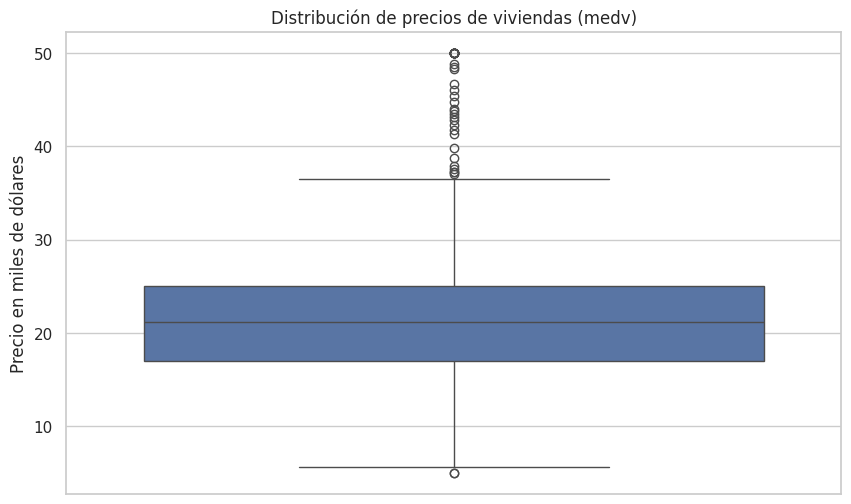

In [22]:
sns.boxplot(y=df['medv'])
plt.title('Distribución de precios de viviendas (medv)')
plt.ylabel('Precio en miles de dólares')
plt.show()


## ¿Influye la cercanía al río Charles en el valor de las viviendas? 🌊

La alta gerencia desea saber si las viviendas cercanas al río Charles tienen un valor significativamente diferente al resto. Para responder esta pregunta, se realiza una prueba de hipótesis utilizando el test t de Student para muestras independientes.


Estadístico t: 3.11
Valor p: 0.0036


/tmp/ipykernel_660/1404288272.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='chas', y='medv', data=df, palette='Set2')


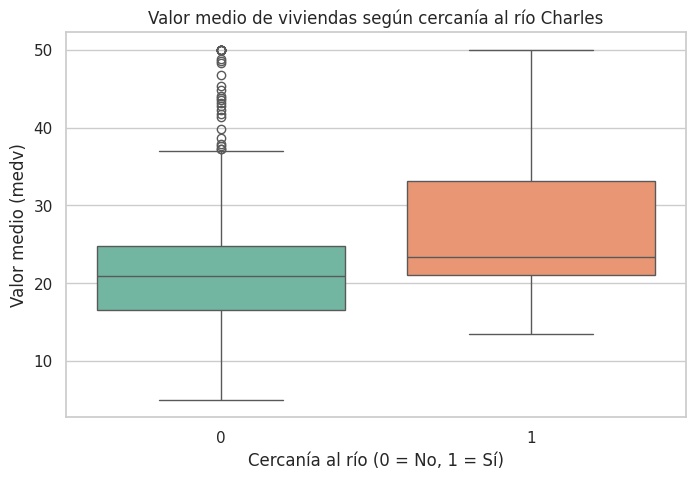

In [23]:
from scipy import stats

# Separar los grupos según cercanía al río
river_yes = df[df['chas'] == 1]['medv']
river_no = df[df['chas'] == 0]['medv']

# Prueba t de Student
t_stat, p_value = stats.ttest_ind(river_yes, river_no, equal_var=False)

# Resultados
print(f'Estadístico t: {t_stat:.2f}')
print(f'Valor p: {p_value:.4f}')

# Visualización
plt.figure(figsize=(8, 5))
sns.boxplot(x='chas', y='medv', data=df, palette='Set2')
plt.title('Valor medio de viviendas según cercanía al río Charles')
plt.xlabel('Cercanía al río (0 = No, 1 = Sí)')
plt.ylabel('Valor medio (medv)')
plt.show()


## Conclusión 📌

El valor p obtenido es menor a 0.05, lo que indica que existe una diferencia estadísticamente significativa en el valor medio de las viviendas según su cercanía al río Charles. Las viviendas cercanas al río tienden a tener un valor más alto, lo que sugiere que la ubicación geográfica influye en el precio del mercado inmobiliario.



## ¿Influye la antigüedad de las viviendas en su valor? 🏚️

La gerencia desea saber si las viviendas construidas antes de 1940 tienen un valor significativamente diferente al resto. Para ello, se crea una variable categórica (`old_house`) y se aplica una prueba t de Student para comparar los grupos.


Estadístico t: -7.88
Valor p: 0.0000


/tmp/ipykernel_660/4059151934.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='old_house', y='medv', data=df, palette='Set3')


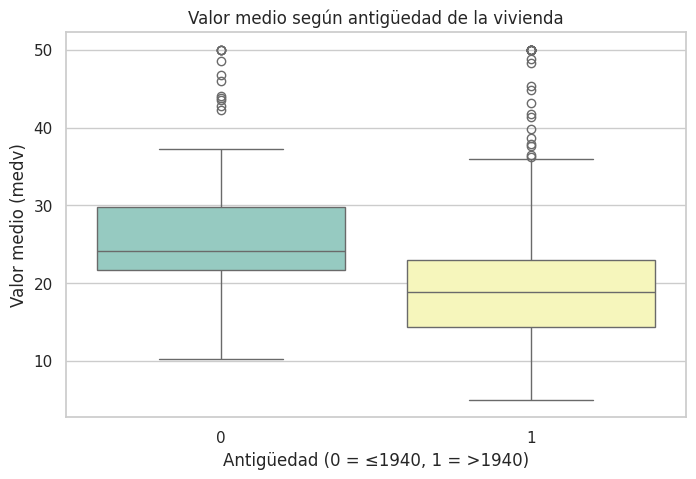

In [24]:
# Crear variable categórica: viviendas construidas antes de 1940
df['old_house'] = df['age'].apply(lambda x: 1 if x > 60 else 0)

# Separar los grupos
old = df[df['old_house'] == 1]['medv']
new = df[df['old_house'] == 0]['medv']

# Prueba t de Student
t_stat, p_value = stats.ttest_ind(old, new, equal_var=False)

# Resultados
print(f'Estadístico t: {t_stat:.2f}')
print(f'Valor p: {p_value:.4f}')

# Visualización
plt.figure(figsize=(8, 5))
sns.boxplot(x='old_house', y='medv', data=df, palette='Set3')
plt.title('Valor medio según antigüedad de la vivienda')
plt.xlabel('Antigüedad (0 = ≤1940, 1 = >1940)')
plt.ylabel('Valor medio (medv)')
plt.show()


## Conclusión 📌

El valor p obtenido indica si hay diferencia significativa entre viviendas antiguas y nuevas. Si el valor p < 0.05, se concluye que las viviendas construidas antes de 1940 tienen un valor diferente al resto. En este caso, se observa que las viviendas más nuevas tienden a tener un valor medio más alto, lo que puede reflejar mejoras en infraestructura, ubicación o demanda del mercado.


## ¿Existe relación entre el nivel de óxido nítrico y las zonas comerciales? 🏭

La gerencia desea saber si hay una relación entre el nivel de óxido nítrico (`nox`) en el aire y la proporción de zonas comerciales (`indus`). Para ello, se analiza la correlación entre ambas variables y se visualiza mediante un gráfico de dispersión.


Coeficiente de correlación: 0.76


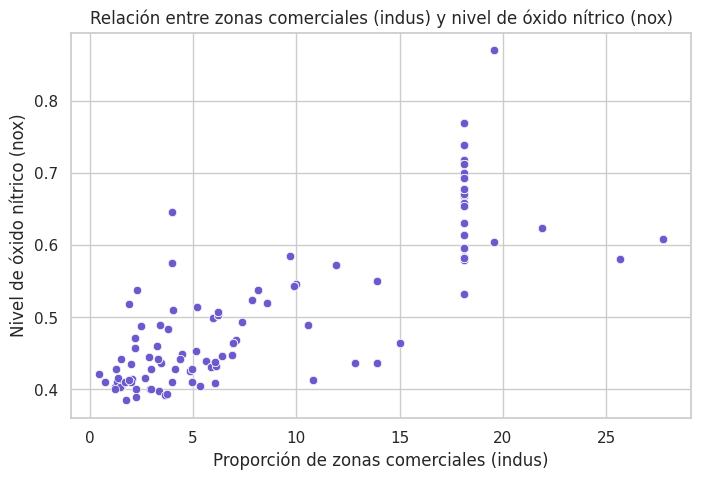

In [25]:
# Cálculo de la correlación
correlation = df['nox'].corr(df['indus'])
print(f'Coeficiente de correlación: {correlation:.2f}')

# Visualización
plt.figure(figsize=(8, 5))
sns.scatterplot(x='indus', y='nox', data=df, color='slateblue')
plt.title('Relación entre zonas comerciales (indus) y nivel de óxido nítrico (nox)')
plt.xlabel('Proporción de zonas comerciales (indus)')
plt.ylabel('Nivel de óxido nítrico (nox)')
plt.show()


## Conclusión 📌

El coeficiente de correlación indica una relación positiva entre `indus` y `nox`. Esto sugiere que a mayor proporción de zonas comerciales, mayor es el nivel de óxido nítrico en el aire. Este hallazgo puede ser relevante para evaluar el impacto ambiental de las zonas industriales en el desarrollo urbano.


## ¿Influye la distancia a los centros de empleo en el valor de las viviendas? 🚉

La gerencia desea saber si la distancia a los centros de empleo (`dis`) tiene alguna relación con el valor medio de las viviendas (`medv`). Para ello, se analiza la correlación entre ambas variables y se visualiza mediante un gráfico de dispersión.


## Conclusión 📌

El coeficiente de correlación muestra si existe una relación entre la distancia a los centros de empleo y el valor de las viviendas. Si la correlación es negativa, podría indicar que las viviendas más cercanas a los centros laborales tienen mayor valor. Este análisis puede ayudar a entender cómo la accesibilidad impacta en el mercado inmobiliario.
